## Confidence Intervals

In [36]:
import pandas as pd
import numpy as np

np.random.seed(42)

coffee_full = pd.read_csv('./coffee_dataset.csv')
coffee_red = coffee_full.sample(200)

print(f'proportion that drinks coffee: {coffee_red.drinks_coffee.mean()}')
print(f'proportion that doesn\'t drink coffee: {1 - coffee_red.drinks_coffee.mean()}')

proportion that drinks coffee: 0.595
proportion that doesn't drink coffee: 0.405


In [24]:
avg_height_drinks_coffee = coffee_red[coffee_red['drinks_coffee'] == True]['height'].mean()
avg_height_not_drinks_coffee = coffee_red[coffee_red['drinks_coffee'] == False]['height'].mean()

print(f'drinks coffee: {avg_height_drinks_coffee}')
print(f'doesn\'t drink coffee: {avg_height_not_drinks_coffee}')

drinks coffee: 68.11962990858616
doesn't drink coffee: 66.78492279927877


In [30]:
bootstrap200 = coffee_red.sample(200, replace=True)
bootstrap200_drinker_mean = bootstrap200.drinks_coffee.mean()

print(f'drinkers from bootstrap sample: {bootstrap200_drinker_mean}')
print(f'non drinkers from bootstrap sample: {1 - bootstrap200_drinker_mean}')


drinkers from bootstrap sample: 0.605
non drinkers from bootstrap sample: 0.395


In [31]:
mean_heights_non_drinkers = []

for _ in range(10000):
    sample200 = coffee_red.sample(200, replace=True)
    mean_heights_non_drinkers.append(sample200[sample200['drinks_coffee'] == False]['height'].mean())


(array([  16.,  106.,  590., 1831., 2989., 2644., 1352.,  377.,   86.,
           9.]),
 array([65.24631713, 65.56293231, 65.8795475 , 66.19616268, 66.51277787,
        66.82939305, 67.14600823, 67.46262342, 67.7792386 , 68.09585379,
        68.41246897]),
 <BarContainer object of 10 artists>)

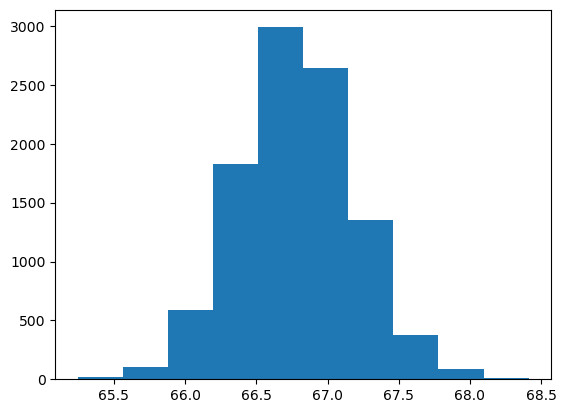

In [32]:
import matplotlib.pyplot as plt
# matplotlib inline

plt.hist(mean_heights_non_drinkers)

In [37]:
print(f'{np.percentile(mean_heights_non_drinkers, 2.5)}')
print(f'{np.percentile(mean_heights_non_drinkers, 97.5)}')

print(f'population mean: {coffee_full[coffee_full['drinks_coffee'] == False]['height'].mean()}')
print(f'sample mean: {avg_height_not_drinks_coffee}')

65.9929132815752
67.58402738281572
population mean: 66.443407762147
sample mean: 66.78492279927877
